# Variational Autoencoder (VAE)

Useful links: 
* Original paper http://arxiv.org/abs/1312.6114
* Helpful videos explaining the topic 
   * https://www.youtube.com/watch?v=P78QYjWh5sM     
   * http://videolectures.net/deeplearning2015_courville_autoencoder_extension/?q=aaron%20courville

### Download data

In [4]:
#!L
# from yfile import download_from_yadisk
# import os

# TARGET_DIR = '.'
# FILENAME = "celeba.zip"

# if not os.path.exists(os.path.join(TARGET_DIR, FILENAME)):
#     # we are going to download 1.4 gb file, downloading will take some time (8-10 minutes)
#     download_from_yadisk(
#         short_url='https://disk.yandex.ru/d/QErNx-MoC-2Y6Q',
#         filename=FILENAME,
#         target_dir=TARGET_DIR
#     )

#     # alternative way: 
#     #from gfile import download_list
#     #download_list(url=https://drive.google.com/file/d/1lwn2JMwWNGloGvyzKUOcewT8JqP1ICoW,
#     #               filename=FILENAME, target_dir=TARGET_DIR)

# filesize = os.path.getsize(os.path.join(TARGET_DIR, FILENAME))
# GB = 2**30
assert filesize > 1 * GB, "{filesize} is too small, something wrong with downloading"

In [5]:
#!L:bash
# !unzip celeba.zip

## Prepare the data

In [6]:
#!L
import numpy as np
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.utils import make_grid

device = torch.device("cuda")

In [7]:
#!L
class CropCelebA64:
    
    def __call__(self, pic):
        new_pic = pic.crop((15, 40, 178 - 15, 218 - 30))
        return new_pic

    def __repr__(self):
        return self.__class__.__name__ + '()'

In [8]:
#!L

# Note that for simplicity we reduce the number of channels to 1
# But if you want to be hardcore feel free to comment .Grayscale :)

train_dataset = torchvision.datasets.CelebA(
    root='celeba',
    split='train',
    transform=torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
        
        torchvision.transforms.Grayscale()
    ]),
    #download=True,   # in case of problems with downloading from gdrive above
)

validation_dataset = torchvision.datasets.CelebA(
    root='celeba',
    split='valid',
    transform=torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.ToTensor(),
        
        torchvision.transforms.Grayscale()
    ]),
)

In [9]:
#!L
# Save first 10k images for evaluation
num_images = 10000
real_images_tensor = torch.stack([train_dataset[i][0] for i in range(num_images)], dim=0)
real_images = real_images_tensor.data.numpy().transpose([0, 2, 3, 1])
np.savez("real.npz", Pictures=real_images.reshape(num_images, 64 * 64 * 1))

In [10]:
#!L
BATCH_SIZE = 64

# you may find useful parameters `num_workers` and `pin_memory`
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

# Autoencoder

Why to use all this complicated formulaes and regularizations, what is the need for variational inference? To analyze the difference, let's first train just an autoencoder on the data:

In [11]:
#!L
dimZ = 100  # Considering face reconstruction task, which size of representation seems reasonable?

# Define the decoder and encoder as networks with one hidden fc-layer
# (that means you will have 2 fc layers in each net)
# Use ReLU for hidden layers' activations
# GlorotUniform initialization for W
# Zero initialization for biases
# It's also convenient to put sigmoid activation on output layer to get nice normalized pics


class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(4096, 256),
            nn.ReLU(),
            nn.Linear(256, dimZ),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(dimZ, 256),
            nn.ReLU(),
            nn.Linear(256, 4096),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.reshape(shape=(x.shape[0], x.shape[1], 4096))
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)

        return reconstruction, latent_code

In [16]:
from tqdm import tqdm as тукудум

In [ ]:
#!L
# Create MSE loss function
criterion = torch.nn.MSELoss()

autoencoder = Autoencoder().to(device)

# Use Adam optimizer
optimizer = optim.Adam(autoencoder.parameters())

In [ ]:
#!L
# Train your autoencoder
# Visualize progress in reconstruction and loss decay
autoencoder.to(device)
epoch_num = 10
train_losses = []
test_losses = []


for epoch in тукудум(range(epoch_num)):
    autoencoder.train()
    total_loss = 0
    for idx, batch in enumerate(train_loader):
        batch = batch[0].to(device)
        optimizer.zero_grad()
        res, _ = autoencoder(batch)
        loss = criterion(res, batch.view(shape=(batch.shape[0], batch.shape[1], 4096)))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    total_loss = 0
    autoencoder.eval()
    with torch.no_grad():
        for idx, batch in тукудум(enumerate(val_loader)):
            batch = batch[0].to(device)
            res, _ = autoencoder(batch)
            loss = criterion(res, batch.reshape(shape=(batch.shape[0], batch.shape[1], 4096)))
            total_loss += loss.item()
    test_losses.append(total_loss / len(val_loader))
    print(f"Train loss: {train_losses[-1]}", f"Val loss: {test_losses[-1]}")

311it [00:14, 22.18it/s]0:00<?, ?it/s]
 10%|█         | 1/10 [02:35<23:15, 155.00s/it]

Train loss: 0.008136172456931873 Val loss: 0.008112617840217816


311it [00:13, 22.72it/s]
 20%|██        | 2/10 [05:02<20:03, 150.47s/it]

Train loss: 0.008023115757958225 Val loss: 0.00801215733632062


311it [00:15, 20.58it/s]
 30%|███       | 3/10 [07:34<17:37, 151.05s/it]

...

Train loss: 0.007555242038277745 Val loss: 0.007554734992671914


311it [00:12, 24.19it/s]
 90%|█████████ | 9/10 [22:02<02:19, 139.44s/it]

Train loss: 0.007526885488754396 Val loss: 0.0076152580966903465


311it [00:12, 24.10it/s]
100%|██████████| 10/10 [24:16<00:00, 145.61s/it]

Train loss: 0.007497977987795764 Val loss: 0.007557420864090372


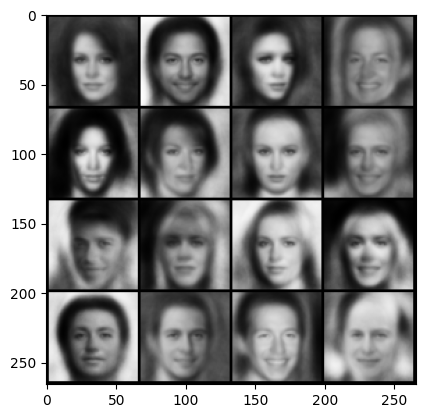

In [ ]:
from itertools import islice

images, _ = list(islice(val_loader, 1))[0]
reconstruction, latent_code = autoencoder(images.to(device))

reconstruction = reconstruction[:16].cpu()
reconstruction = reconstruction.view(-1, 1, 64, 64)
grid = make_grid(reconstruction, nrow=4, padding=0, normalize=True)
grid_img = grid.permute(1, 2, 0).squeeze(-1).numpy()
plt.imshow(grid_img)

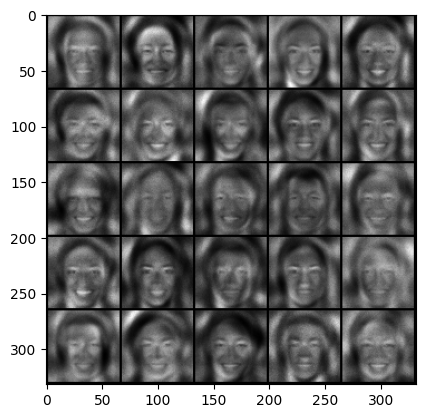

In [ ]:
#!L
# Examine the reconstructions
z = torch.randn(25, dimZ) * 0.4
reconstruction = nn.functional.sigmoid(autoencoder.decoder(z.to(device)))

reconstruction = reconstruction.view(-1, 1, 64, 64).cpu()
grid = make_grid(reconstruction, nrow=5, padding=0, normalize=True)
grid_img = grid.permute(1, 2, 0).squeeze(-1).numpy()
plt.imshow(grid_img)

Reconstruction is not bad, right? 

# Sampling

Let's now sample several latent vectors and perform inference from $z$, reconstruct an image given some random $z$ representations.

So, if we sample $z$ from normal, whould we eventually generate all possible faces? What do you think?

# Variational Autoencoder

Bayesian approach in deep learning considers everything in terms of distributions. Now our encoder generates not just a vector $z$ but posterior ditribution $q(z|x)$. In our case distribution $q$ is Gaussian distibution $N(\mu, \sigma)$ with parameters $\mu$, $\sigma$. Technically, the first difference is that you need to split bottleneck layer in two. One dense layer will generate vector $\mu$, and another will generate vector $\sigma$. Reparametrization trick should be implemented using the **gaussian_sampler** layer, that generates random vetor $\epsilon$ and returns $\mu+\sigma\epsilon \sim N(\mu, \sigma)$ .

Since our decoder is also a function that generates distribution, we need to do the same splitting for output layer. When testing the model we will look only on mean values, so one of the output will be actual autoencoder output.

In this homework we only ask for implementation of the simplest version of VAE - one $z$ sample per input. You can consider to sample several outputs from one input and average them.

In [13]:
import torch.nn.functional as F
#!L
# to compare with conventional AE, keep these hyperparameters
# or change them for the values that you used before
dimZ = 100

# define the network
# you can start from https://github.com/pytorch/examples/blob/master/vae/main.py
# or Theano-based examples here https://github.com/Lasagne/Recipes/blob/master/examples/variational_autoencoder/variational_autoencoder.py
# and here https://github.com/y0ast/Variational-Autoencoder/blob/master/VAE.py
# but remember that this is not your ground truth since the data is not MNIST


class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        
        self.encoder_fc1 = nn.Linear(4096, 256)
        self.encoder_fc2 = nn.Linear(256, dimZ)
        self.encoder_fc3 = nn.Linear(256, dimZ)

        self.decoder_fc1 = nn.Linear(dimZ, 256)
        self.decoder_fc2 = nn.Linear(256, 4096)
        self.decoder_fc3 = nn.Linear(256, 4096)

    def gaussian_sampler(self, mu, logsigma):
        noise = torch.randn_like(mu)
        return noise * logsigma.exp() + mu

    def forward(self, x):
        x = x.view(x.size(0), -1)
        hidden_encoder = F.relu(self.encoder_fc1(x))
        latent_mu = self.encoder_fc2(hidden_encoder)
        latent_logsigma = self.encoder_fc3(hidden_encoder)

        sample = self.gaussian_sampler(latent_mu, latent_logsigma)

        hidden_decoder = F.relu(self.decoder_fc1(sample))
        reconstruction_mu = F.sigmoid(self.decoder_fc2(hidden_decoder))
        reconstruction_logsigma = self.decoder_fc3(hidden_decoder)
        
        return reconstruction_mu, reconstruction_logsigma, latent_mu, latent_logsigma

And the last, but not least! Place in the code where the most of the formulaes goes to - optimization objective. The objective for VAE has it's own name - variational lowerbound. And as for any lowerbound our intention is to maximize it. Here it is (for one sample $z$ per input $x$):

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z) \to max$$

Your next task is to implement two functions that compute KL-divergence and the second term - log-likelihood of an output. Here is some necessary math for your convenience:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$
$$\log p_{\theta}(x|z) = \sum_{i=1}^{dimX}\log p_{\theta}(x_i|z)=\sum_{i=1}^{dimX} \log \Big( \frac{1}{\sigma_i\sqrt{2\pi}}e^{-\frac{(\mu_i-x)^2}{2\sigma_i^2}} \Big)=...$$

Don't forget in the code that you are using $\log\sigma$ as variable. Explain, why not $\sigma$?

In [54]:
#!L
def KL_divergence(mu, logsigma):
    return -torch.sum(1 + 2 * logsigma - mu**2 - torch.exp(2 * logsigma), dim=1) / 2.

def log_likelihood(x, mu, logsigma):
    log_prob = (2 * logsigma + (x - mu)**2 / torch.exp(2 * logsigma) + np.log(2 * torch.pi))
    return torch.sum(log_prob, dim=1)

def loss_vae(x, mu_gen, logsigma_gen, mu_z, logsigma_z):
    kl = KL_divergence(mu_z, logsigma_z)
    log_p = log_likelihood(x, mu_gen, logsigma_gen)
    loss = -kl + log_p
    return torch.mean(loss)

And train the model:

In [ ]:
#!L
# train your variational autoencoder
# visualize progress in reconstruction and loss decay

vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=3e-3)

train_losses = []
num_epochs = 10

for epoch in тукудум(range(num_epochs)):
    vae.train()
    total_loss = 0.0
    batch_num = 0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        x_flat = x_batch.view(x_batch.size(0), -1)

        optimizer.zero_grad()
        recon_mu, recon_logsigma, latent_mu, latent_logsigma = vae(x_batch)
        loss = loss_vae(x_flat, recon_mu, recon_logsigma, latent_mu, latent_logsigma)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        # batch_num += 1
        # # print(batch_num)
        # if batch_num == 100:
        #     break

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_losses[-1]}")

 10%|█         | 1/10 [02:34<23:10, 154.52s/it]

Epoch 1/10, Loss: -2804.1418


 20%|██        | 2/10 [04:42<18:32, 139.08s/it]

Epoch 2/10, Loss: -3732.8477


 30%|███       | 3/10 [06:54<15:51, 135.92s/it]

...

Epoch 8/10, Loss: -4159.3738


 90%|█████████ | 9/10 [19:52<02:09, 129.70s/it]

Epoch 9/10, Loss: -4177.7820


100%|██████████| 10/10 [22:01<00:00, 132.14s/it]

Epoch 10/10, Loss: -4187.0296


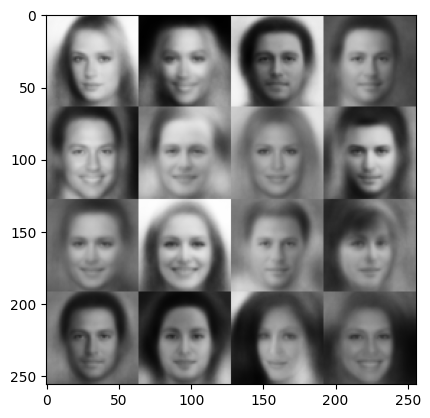

In [86]:
#!L
from itertools import islice

images, _ = list(islice(val_loader, 1))[0]
mu_gen, _, _, _ = vae(images.to(device))
reconstruction = mu_gen[10:26].cpu()

reconstruction = reconstruction.view(-1, 1, 64, 64).cpu()
grid = make_grid(reconstruction, nrow=4, padding=0, normalize=True)
grid_img = grid.permute(1, 2, 0).squeeze(-1).numpy()
plt.imshow(grid_img)

And finally sample from VAE.

In [74]:
def sample_vae(vae, num_samples,):
    vae.eval()
    z = torch.randn(num_samples, dimZ).to(device)*0.5
    with torch.no_grad():
        h = F.relu(vae.decoder_fc1(z))
        mu = F.sigmoid(vae.decoder_fc2(h))
        mu = mu.view(-1, 1, 64, 64)
        return mu

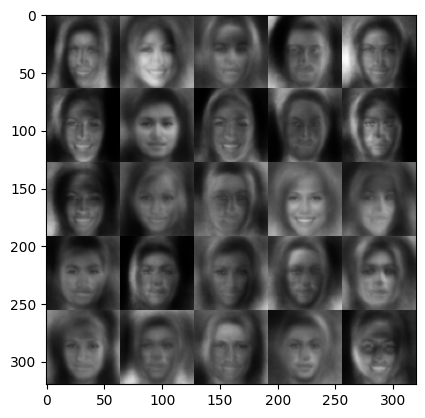

In [85]:
#!L
reconstruction = sample_vae(vae, 25)
reconstruction = reconstruction.view(-1, 1, 64, 64).cpu()
grid = make_grid(reconstruction, nrow=5, padding=0, normalize=True)
grid_img = grid.permute(1, 2, 0).squeeze(-1).numpy()
plt.imshow(grid_img)

Even if in practice you do not see the much difference between AE and VAE, or VAE is even worse, the little bayesian inside you should be jumping for joy right now. 

In VAE you can truly sample from image distribution $p(x)$, while in AE there is no easy and correct way to do it. 

# Congrats! and Bonus

If you managed to tune your autoencoders to converge and learn something about the world, now it's time to make fun out of it. As you may have noticed, there are face attributes in dataset. We're interesting in "Smiling" column (index 31 of the attribute vector), but feel free to try others as well! Here is the first task:

1) Extract the "Smilling" attribute and create a two sets of images: 10 smiling faces and 10 non-smiling ones.

2) Compute latent representations for each image in "smiling" set and average those latent vectors. Do the same for "non-smiling" set. You have found **"vector representation"** of the "smile" and "no smile" attribute.

3) Compute the difference: "smile" vector minus "non-smile" vector.

3) Now check if **"feature arithmetics"** works. Sample a face without smile, encode it and add the diff from p. 3. Check if it works with both AE and VAE. 

<img src="linear.png" alt="linear">

In [55]:
def extract_pic(type):
    pics = []
    for images, attr in train_loader:
        tensor = attr[:, 31] == type

        for img in images[tensor]:
            pics.append(img)
        
        if len(pics) > 100:
            break
    return pics

In [57]:
smile = torch.stack(extract_pic(1)).to(device)
sad = torch.stack(extract_pic(0)).to(device)

In [65]:
def comp_vae(x):
    vae.eval()
    with torch.no_grad():
        x_flat = x.view(x.shape[0], -1)
        hidden_encoder = F.relu(vae.encoder_fc1(x_flat))
        latent_mu = vae.encoder_fc2(hidden_encoder)
        return latent_mu
    
def decode(x):
    vae.eval()
    with torch.no_grad():
        h = F.relu(vae.decoder_fc1(x))
        decoded = F.sigmoid(vae.decoder_fc2(h)).view(1, 1, 64, 64)
    return decoded

In [61]:
dir = comp_vae(smile).mean(0) - comp_vae(sad).mean(0)

In [62]:
sad_sample = sad[5]

In [66]:
sad_vae = comp_vae(sad_sample).mean(0)
smiled_recon = decode(sad_vae + dir)

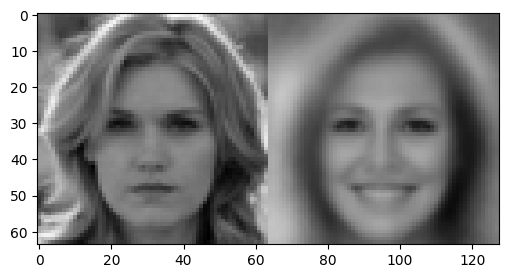

In [87]:
orig = sad_sample.cpu()
vae_result = smiled_recon.cpu()
comparison = torch.cat([orig.unsqueeze(0), vae_result], dim=0)

grid = make_grid(comparison, nrow=2, padding=0, normalize=True)
plt.figure(figsize=(8, 3))
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
plt.show()